In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter


In [8]:
os.makedirs("figures", exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

WAR_START = pd.Timestamp("2022-02-24")

COLORS = {
    "Drone": "#d73027",
    "Artillery": "#4575b4",
    "Armored warfare": "#4d4d4d",
    "Airstrike": "#fdae61"
}


In [9]:
ukr_database = pd.read_csv(
    "data/uadatabase.csv",
    low_memory=False
)

event2022 = pd.read_csv(
    "data/event_1pd_latest_2022.csv",
    low_memory=False
)
event2023 = pd.read_csv(
    "data/event_1pd_latest_2023.csv",
    low_memory=False
)
event2024 = pd.read_csv(
    "data/event_1pd_latest_2024.csv",
    low_memory=False
)
event2025 = pd.read_csv(
    "data/event_1pd_latest_2025.csv",
    low_memory=False
)
event2026 = pd.read_csv(
    "data/event_1pd_latest_2026.csv",
    low_memory=False
)

poteru = pd.read_csv(
    "data/poteru_rus.csv",
    low_memory=False
)

rus_officers = pd.read_csv(
    "data/rus_ofc_kia.csv",
    low_memory=False
)



In [10]:
events = pd.concat(
    [
        event2022,
        event2023,
        event2024,
        event2025,
        event2026
    ],
    ignore_index=True
)

raw_dates = (
    events["date"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

compact_dates = pd.to_datetime(
    raw_dates,
    format="%Y%m%d",
    errors="coerce"
)

formatted_dates = pd.to_datetime(
    raw_dates,
    errors="coerce"
)

events["date"] = compact_dates.fillna(formatted_dates)

events = events[
    events["date"].notna()
    & (events["date"] >= WAR_START)
].copy()

events["month"] = (
    events["date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

binary_columns = [
    "t_mil_b",
    "t_uav_b",
    "t_artillery_b",
    "t_armor_b",
    "t_airstrike_b",
    "t_milcas_b",
    "t_civcas_b"
]

for column in binary_columns:
    events[column] = (
        pd.to_numeric(events[column], errors="coerce")
        .fillna(0)
        .gt(0.5)
    )

military_events = events.loc[
    events["t_mil_b"]
].copy()

tactics = {
    "Drone": "t_uav_b",
    "Artillery": "t_artillery_b",
    "Armored warfare": "t_armor_b",
    "Airstrike": "t_airstrike_b"
}

print("Total events:", len(events))
print("Military events:", len(military_events))
print("Missing months:", military_events["month"].isna().sum())
print(
    "Date range:",
    events["date"].min(),
    "to",
    events["date"].max()
)


Total events: 407857
Military events: 307793
Missing months: 0
Date range: 2022-02-24 00:00:00 to 2026-07-28 00:00:00


Months in graph: 54
               Drone  Artillery  Armored warfare  Airstrike
month                                                      
2022-02-01  2.303038  26.166183         2.492313   6.567874
2022-03-01  2.063173  26.981821         2.161577   5.730528
2022-04-01  2.030786  29.002113         1.469946   5.000317
2022-05-01  1.860649  30.687837         1.105211   4.186647
2022-06-01  1.836083  32.680208         0.830770   4.339485


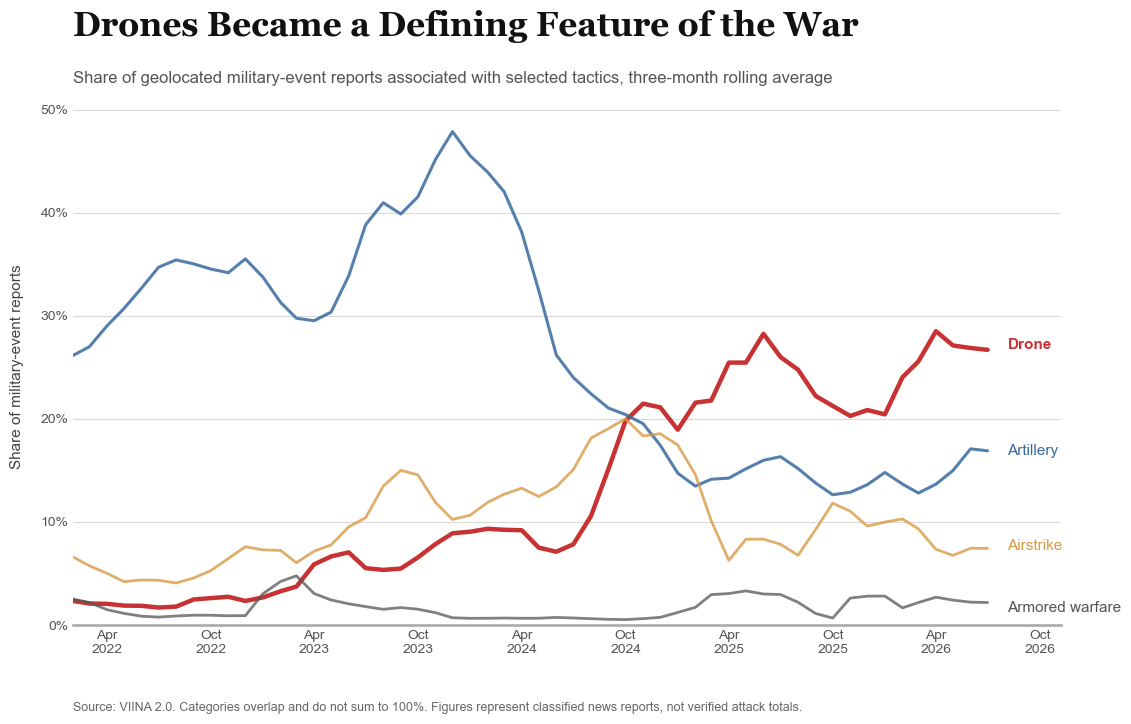

In [13]:
monthly_total = (
    military_events
    .groupby("month")
    .size()
)

tactic_share = pd.DataFrame(
    index=monthly_total.index
)

for label, column in tactics.items():
    monthly_count = (
        military_events
        .groupby("month")[column]
        .sum()
    )

    tactic_share[label] = (
        monthly_count
        .div(monthly_total)
        .mul(100)
    )

tactic_share_smoothed = tactic_share.rolling(
    window=3,
    center=True,
    min_periods=1
).mean()

print("Months in graph:", len(tactic_share_smoothed))
print(tactic_share_smoothed.head())

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, ax = plt.subplots(figsize=(13, 7.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plot_styles = {
    "Drone": {
        "color": "#C83232",
        "linewidth": 3.2,
        "alpha": 1.0
    },
    "Artillery": {
        "color": "#376A9F",
        "linewidth": 2.2,
        "alpha": 0.85
    },
    "Armored warfare": {
        "color": "#555555",
        "linewidth": 2.0,
        "alpha": 0.75
    },
    "Airstrike": {
        "color": "#D99A45",
        "linewidth": 2.0,
        "alpha": 0.8
    }
}

for tactic in tactic_share_smoothed.columns:
    style = plot_styles[tactic]

    ax.plot(
        tactic_share_smoothed.index,
        tactic_share_smoothed[tactic],
        color=style["color"],
        linewidth=style["linewidth"],
        alpha=style["alpha"]
    )


label_offsets = {
    "Drone": 0.5,
    "Artillery": 0.0,
    "Armored warfare": -0.5,
    "Airstrike": 0.3
}

last_date = tactic_share_smoothed.index.max()
label_date = last_date + pd.Timedelta(days=35)

for tactic in tactic_share_smoothed.columns:
    final_value = (
        tactic_share_smoothed[tactic]
        .dropna()
        .iloc[-1]
    )

    ax.text(
        label_date,
        final_value + label_offsets[tactic],
        tactic,
        color=plot_styles[tactic]["color"],
        fontsize=11,
        fontfamily="Arial",
        fontweight=(
            "bold" if tactic == "Drone" else "normal"
        ),
        va="center"
    )

fig.suptitle(
    "Drones Became a Defining Feature of the War",
    x=0.08,
    y=0.97,
    ha="left",
    fontsize=24,
    fontweight="bold",
    fontfamily="Georgia",
    color="#111111"
)

ax.set_title(
    "Share of geolocated military-event reports associated "
    "with selected tactics, three-month rolling average",
    loc="left",
    fontsize=12,
    fontfamily="Arial",
    color="#555555",
    pad=18
)

ax.set_ylabel(
    "Share of military-event reports",
    fontsize=11,
    fontfamily="Arial",
    color="#444444",
    labelpad=12
)

ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=0
    )
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.set_xlim(
    tactic_share_smoothed.index.min(),
    last_date + pd.Timedelta(days=130)
)

ax.set_ylim(bottom=0)

ax.grid(
    axis="y",
    color="#D9D9D9",
    linewidth=0.8
)

ax.grid(
    axis="x",
    visible=False
)

for spine in [
    "top",
    "right",
    "left"
]:
    ax.spines[spine].set_visible(False)

ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    which="both",
    length=0,
    labelsize=10,
    colors="#555555"
)

legend = ax.get_legend()

if legend is not None:
    legend.remove()

fig.text(
    0.08,
    0.035,
    "Source: VIINA 2.0. Categories overlap and do not sum to 100%. "
    "Figures represent classified news reports, not verified attack totals.",
    ha="left",
    fontsize=9,
    fontfamily="Arial",
    color="#666666"
)

plt.subplots_adjust(
    left=0.08,
    right=0.84,
    top=0.84,
    bottom=0.15
)


plt.savefig(
    "figures/01_viina_tactic_shares_editorial.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()